# Goal:

The goal of this document is to see how a decison tree, and random forest compare to the logistic regression I already did on the epl dataset

# The logistic Regression had an accuracy of 77% and and auc of 87%

In [2]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Loading in EPL 2023/24 match results
path = r"C:\Users\jahg9\OneDrive\Documents\Data Analysis Projects\EPL Match Prediction\epl_merged.csv"
epl_merged = pd.read_csv(path)

In [41]:
epl_merged['win'].unique()

array([1, 0])

# Data Setup and Preparation

In [44]:
features = [
    'xGD',
    'SoT',
    'Opp_SoT',
    'sot_diff',
    'Poss',
    'home'
]


df = epl_merged.copy()

X = df[features]
y = df['win']

from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

tree.fit(train_X, train_y)


DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)

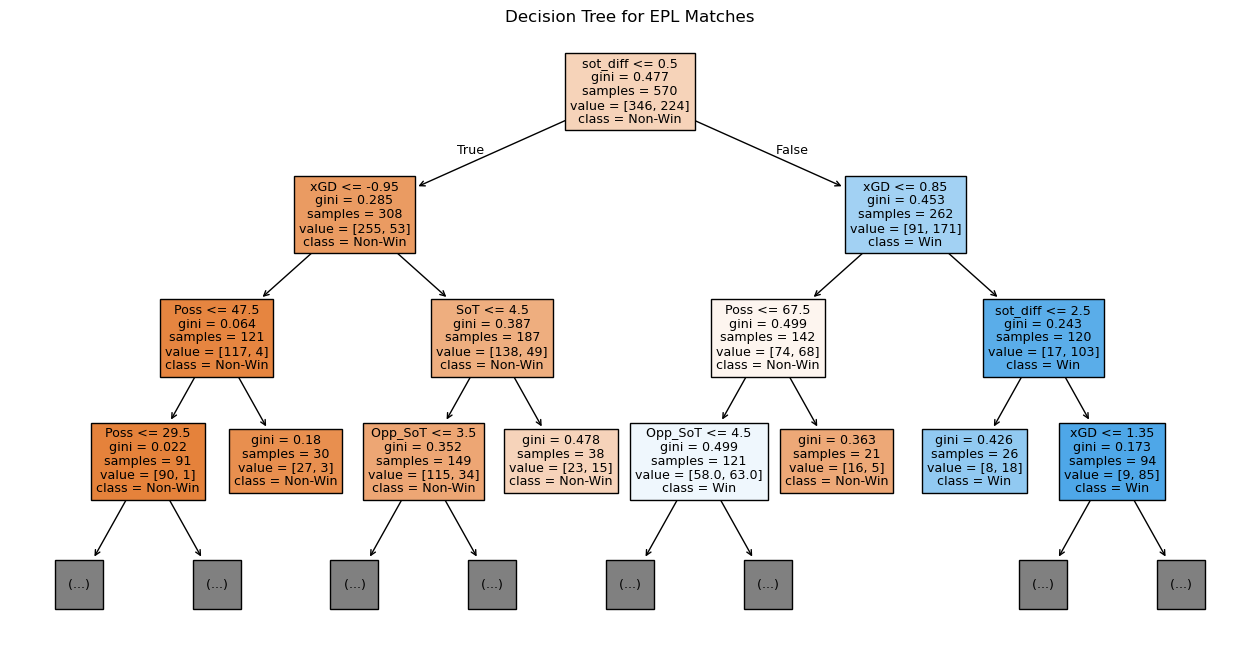

In [45]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    tree,
    feature_names=train_X.columns,
    filled=True,
    max_depth=3,
    class_names=['Non-Win', 'Win']
)
plt.title("Decision Tree for EPL Matches")
plt.show()


In [46]:
# Class predictions (0/1)
pred_tree = tree.predict(test_X)

# Predicted probabilities (needed for ROC / AUC)
pred_tree_prob = tree.predict_proba(test_X)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

accuracy_tree = accuracy_score(test_y, pred_tree)
auc_tree = roc_auc_score(test_y, pred_tree_prob)
cm_tree = confusion_matrix(test_y, pred_tree)



In [47]:
print(f"This model achieved an AUC of {auc_tree *100} and an accuracy of {accuracy_tree}")


This model achieved an AUC of 83.23042870456665 and an accuracy of 0.7631578947368421


# This Decison Tree model achieved an AUC of 83% and an accuracy of 76%

In [48]:
tree_test_df = test_X.copy()
tree_test_df['win'] = test_y.values

tree_test_df['Pred'] = pred_tree_prob

tree_test_df.loc[tree_test_df['win'] == 1,['win', 'Pred']].head(10)



,win,Pred
277,1,0.191667
432,1,0.554455
133,1,0.692308
651,1,0.000000
233,1,0.941176
632,1,0.941176
429,1,0.941176
227,1,0.350000
288,1,0.554455
310,1,0.807692


# Running Tally

Logistic regression AUC: 87%


Decision tree AUC: 83%

# Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,      # number of trees
    max_depth=6,           # prevent overfitting
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

rf.fit(train_X, train_y)

RandomForestClassifier(max_depth=6, min_samples_leaf=10, n_estimators=500,
                       n_jobs=-1, random_state=42)

In [50]:
#Generate Predictions
rf_pred = rf.predict(test_X)
rf_pred_prob = rf.predict_proba(test_X)[:,1]

In [51]:
#Generate Metrics
from sklearn.metrics import accuracy_score, roc_auc_score

rf_accuracy = accuracy_score(test_y, rf_pred)
rf_auc = roc_auc_score(test_y, rf_pred_prob)

rf_accuracy, rf_auc

(0.8052631578947368, np.float64(0.8570596458527494))

In [52]:
importances = pd.Series(
    rf.feature_importances_,
    index=train_X.columns
).sort_values(ascending=False)

importances.head(10)

xGD         0.309817
sot_diff    0.309676
SoT         0.153558
Opp_SoT     0.141904
Poss        0.073859
home        0.011187
dtype: float64

In [53]:
import pandas as pd

pd.DataFrame([
    ["Logistic Regression", .87 * 100],
    ["Decision Tree", auc_tree * 100],
    ["Random Forest", rf_auc *100]
], columns=["Model", "AUC"])

,Model,AUC
0,Logistic Regression,87.000000
1,Decision Tree,83.230429
2,Random Forest,85.705965


In [54]:
train_X.columns

Index(['xGD', 'SoT', 'Opp_SoT', 'sot_diff', 'Poss', 'home'], dtype='object')

# When models were aligned on the same feature set, logistic regression outperformed tree-based models, suggesting the relationship between match performance metrics and win probability is largely linear.